**Nama :** Muhammad Dhiauddin<br>
**NIM :** 25917024<br>
**Konsentrasi :** Sains Data - Profesional<br>
**Mata Kuliah :** Text Analitik<br>
**Tugas :** Text Classification - Machine Learning for Text Analytics<br>

---

# Advanced Sentiment Analysis (Tuned & Fixed Version)
Modifikasi skrip secara mendalam mencakup POS-Lemmatization, Pipeline, Logistic Regression, LinearSVC, Multinomial Naive Bayes (MNB), Hyperparameter Tuning (GridSearchCV) penuh pada semua model, dan visualisasi (Confusion Matrix & ROC-AUC) dengan tema warna biru awan.
**Pembaruan Kritis:** Telah diterapkan perlindungan kata negasi (Custom Stopwords) agar fitur Bigram berfungsi maksimal, serta penerapan Stratify Split dan GridSearch menyeluruh untuk 3 Model Klasifikasi Utama.

In [ ]:
# from google.colab import drive
# drive.mount('/content/drive')

In [20]:
import pandas as pd
import numpy as np
import re
import nltk
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

dataset = pd.read_csv("https://raw.githubusercontent.com/hattafudholi/dataset/refs/heads/master/IMDB%20Dataset.csv")

In [21]:
print("Shape of dataset:", dataset.shape)
dataset.head()

Shape of dataset: (50000, 2)


,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [22]:
features = dataset['review']
labels = dataset['sentiment']

In [23]:
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('averaged_perceptron_tagger_eng')
from nltk.corpus import stopwords

# PERBAIKAN KRITIS: Membuat Custom Stopwords dengan mengecualikan kata-kata negasi penting
stop_words_set = set(stopwords.words('english'))
negation_words = {'not', 'no', 'nor', 'against', 'don', "don't", 'ain', 'aren', "aren't", 'couldn', 
                "couldn't", 'didn', "didn't", 'doesn', "doesn't", 'hadn', "hadn't", 'hasn', "hasn't", 'haven', 
                "haven't", 'isn', "isn't", 'mightn', "mightn't", 'mustn', "mustn't", 'needn', "needn't", 'shan', 
                "shan't", 'shouldn', "shouldn't", 'wasn', "wasn't", 'weren', "weren't", 'won', "won't", 'wouldn', "wouldn't"}
custom_stopwords = list(stop_words_set - negation_words)

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\IT\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\IT\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     C:\Users\IT\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!


In [24]:
from nltk.stem import WordNetLemmatizer
from nltk.corpus import wordnet
import nltk

lemmatizer = WordNetLemmatizer()
tag_dict = {"J": wordnet.ADJ, "N": wordnet.NOUN, "V": wordnet.VERB, "R": wordnet.ADV}

processed_features = []

for sentence in features:
    # 1. Bersihkan tag HTML
    processed_feature = re.sub(r'<.*?>', ' ', str(sentence))
    # 2. Bersihkan special characters
    processed_feature = re.sub(r'\W', ' ', processed_feature)
    # 3. Bersihkan single characters
    processed_feature= re.sub(r'\s+[a-zA-Z]\s+', ' ', processed_feature)
    processed_feature = re.sub(r'^[a-zA-Z]\s+', '', processed_feature)
    # 4. Ganti spasi berlebih
    processed_feature = re.sub(r'\s+', ' ', processed_feature, flags=re.I)
    # 5. Hapus prefix 'b'
    processed_feature = re.sub(r'^b\s+', '', processed_feature)
    # 6. Lowercase
    processed_feature = processed_feature.lower()
    
    # 7. Advanced POS-based Lemmatization
    words = processed_feature.split()
    pos_tags = nltk.pos_tag(words)
    words = [lemmatizer.lemmatize(w, tag_dict.get(pos[0].upper(), wordnet.NOUN)) for w, pos in pos_tags]
    processed_feature = ' '.join(words)
    
    processed_features.append(processed_feature)

In [25]:
# Label Encoding for Models and ROC AUC
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
encoded_labels = le.fit_transform(labels) # 'negative' -> 0, 'positive' -> 1

In [26]:
from sklearn.model_selection import train_test_split
# PERBAIKAN: Menambahkan 'stratify=encoded_labels' untuk pembagian data yang anti bias
X_train, X_test, y_train, y_test = train_test_split(processed_features, encoded_labels, test_size=0.2, random_state=0, stratify=encoded_labels)

In [27]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_curve, auc, roc_auc_score

# Inisiasi dictionary untuk menampung hasil evaluasi semua model
model_results = {'Model': [], 'Accuracy': [], 'ROC-AUC': []}
roc_data = {}

### 1. Advanced: Logistic Regression (Tuned dengan GridSearch & Custom Stopwords)

In [28]:
# Membuat Pipeline untuk mencegah data leakage
pipeline_lr = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=2500, min_df=7, max_df=0.8, stop_words=custom_stopwords, ngram_range=(1,2))),
    ('clf', LogisticRegression(max_iter=500))
])

# GridSearchCV untuk mencari parameter C terbaik secara otomatis
param_grid = {
    'clf__C': [0.1, 1, 10]
}
grid_lr = GridSearchCV(pipeline_lr, param_grid, cv=3, n_jobs=-1, scoring='accuracy')
grid_lr.fit(X_train, y_train)

print("Best Parameters found for Logistic Regression:", grid_lr.best_params_)
best_lr = grid_lr.best_estimator_

predictions_lr = best_lr.predict(X_test)
probs_lr = best_lr.predict_proba(X_test)[:, 1]

acc_lr = accuracy_score(y_test, predictions_lr)
auc_lr = roc_auc_score(y_test, probs_lr)
model_results['Model'].append('Logistic Regression (GridSearch)')
model_results['Accuracy'].append(acc_lr)
model_results['ROC-AUC'].append(auc_lr)

fpr_lr, tpr_lr, _ = roc_curve(y_test, probs_lr)
roc_data['Logistic Regression'] = (fpr_lr, tpr_lr, auc_lr)

print("Accuracy:", acc_lr)
print(classification_report(y_test, predictions_lr))

Best Parameters found for Logistic Regression: {'clf__C': 1}
Accuracy: 0.8852
              precision    recall  f1-score   support

           0       0.89      0.88      0.88      5000
           1       0.88      0.90      0.89      5000

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000



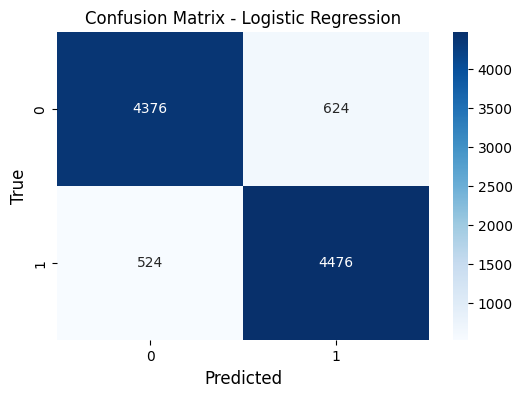

In [29]:
# Plot Confusion Matrix untuk Logistic Regression
matrix_lr = confusion_matrix(y_test, predictions_lr)
plt.figure(figsize=(6, 4))
sns.heatmap(matrix_lr, annot=True, fmt='g', cmap='Blues')
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('True', fontsize=12)
plt.title('Confusion Matrix - Logistic Regression')
plt.show()

### 2. Advanced: Linear Support Vector Classifier (Tuned dengan GridSearch)

In [30]:
from sklearn.svm import LinearSVC

# GridSearchCV untuk LinearSVC
pipeline_svc = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=2500, min_df=7, max_df=0.8, stop_words=custom_stopwords, ngram_range=(1,2))),
    ('clf', LinearSVC(random_state=0, max_iter=2000))
])

param_grid_svc = {
    'clf__C': [0.1, 1, 10]
}
grid_svc = GridSearchCV(pipeline_svc, param_grid_svc, cv=3, n_jobs=-1, scoring='accuracy')
grid_svc.fit(X_train, y_train)

print("Best Parameters found for LinearSVC:", grid_svc.best_params_)
best_svc = grid_svc.best_estimator_

predictions_svc = best_svc.predict(X_test)
decision_scores_svc = best_svc.decision_function(X_test)

acc_svc = accuracy_score(y_test, predictions_svc)
auc_svc = roc_auc_score(y_test, decision_scores_svc)
model_results['Model'].append('LinearSVC (GridSearch)')
model_results['Accuracy'].append(acc_svc)
model_results['ROC-AUC'].append(auc_svc)

fpr_svc, tpr_svc, _ = roc_curve(y_test, decision_scores_svc)
roc_data['LinearSVC'] = (fpr_svc, tpr_svc, auc_svc)

print("Accuracy:", acc_svc)
print(classification_report(y_test, predictions_svc))

Best Parameters found for LinearSVC: {'clf__C': 0.1}
Accuracy: 0.8871
              precision    recall  f1-score   support

           0       0.90      0.87      0.89      5000
           1       0.88      0.90      0.89      5000

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000



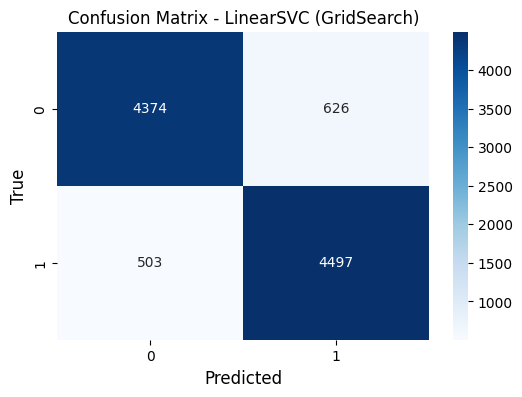

In [31]:
# Plot Confusion Matrix untuk LinearSVC
matrix_svc = confusion_matrix(y_test, predictions_svc)
plt.figure(figsize=(6, 4))
sns.heatmap(matrix_svc, annot=True, fmt='g', cmap='Blues')
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('True', fontsize=12)
plt.title('Confusion Matrix - LinearSVC (GridSearch)')
plt.show()

### 3. Advanced: Multinomial Naive Bayes (Tuned dengan GridSearch)

In [32]:
from sklearn.naive_bayes import MultinomialNB

# Pipeline untuk Multinomial Naive Bayes
pipeline_mnb = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=2500, min_df=7, max_df=0.8, stop_words=custom_stopwords, ngram_range=(1,2))),
    ('clf', MultinomialNB())
])

# GridSearchCV untuk mencari parameter alpha (smoothing) terbaik
param_grid_mnb = {
    'clf__alpha': [0.1, 0.5, 1.0, 2.0, 5.0]
}
grid_mnb = GridSearchCV(pipeline_mnb, param_grid_mnb, cv=3, n_jobs=-1, scoring='accuracy')
grid_mnb.fit(X_train, y_train)

print("Best Parameters found for MultinomialNB:", grid_mnb.best_params_)
best_mnb = grid_mnb.best_estimator_

predictions_mnb = best_mnb.predict(X_test)
probs_mnb = best_mnb.predict_proba(X_test)[:, 1]

acc_mnb = accuracy_score(y_test, predictions_mnb)
auc_mnb = roc_auc_score(y_test, probs_mnb)
model_results['Model'].append('MultinomialNB (GridSearch)')
model_results['Accuracy'].append(acc_mnb)
model_results['ROC-AUC'].append(auc_mnb)

fpr_mnb, tpr_mnb, _ = roc_curve(y_test, probs_mnb)
roc_data['MultinomialNB'] = (fpr_mnb, tpr_mnb, auc_mnb)

print("Accuracy:", acc_mnb)
print(classification_report(y_test, predictions_mnb))

Best Parameters found for MultinomialNB: {'clf__alpha': 5.0}
Accuracy: 0.8518
              precision    recall  f1-score   support

           0       0.86      0.84      0.85      5000
           1       0.84      0.87      0.85      5000

    accuracy                           0.85     10000
   macro avg       0.85      0.85      0.85     10000
weighted avg       0.85      0.85      0.85     10000



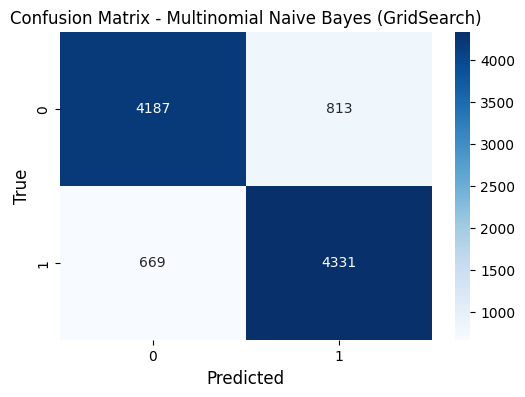

In [33]:
# Plot Confusion Matrix untuk Multinomial Naive Bayes
matrix_mnb = confusion_matrix(y_test, predictions_mnb)
plt.figure(figsize=(6, 4))
sns.heatmap(matrix_mnb, annot=True, fmt='g', cmap='Blues')
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('True', fontsize=12)
plt.title('Confusion Matrix - Multinomial Naive Bayes (GridSearch)')
plt.show()

### 4. Evaluation Summary & ROC Curve

In [34]:
results_df = pd.DataFrame(model_results)
results_df.to_csv("evaluation_results_advanced.csv", index=False)
results_df

,Model,Accuracy,ROC-AUC
0,Logistic Regression (GridSearch),0.8852,0.952684
1,LinearSVC (GridSearch),0.8871,0.952953
2,MultinomialNB (GridSearch),0.8518,0.930174


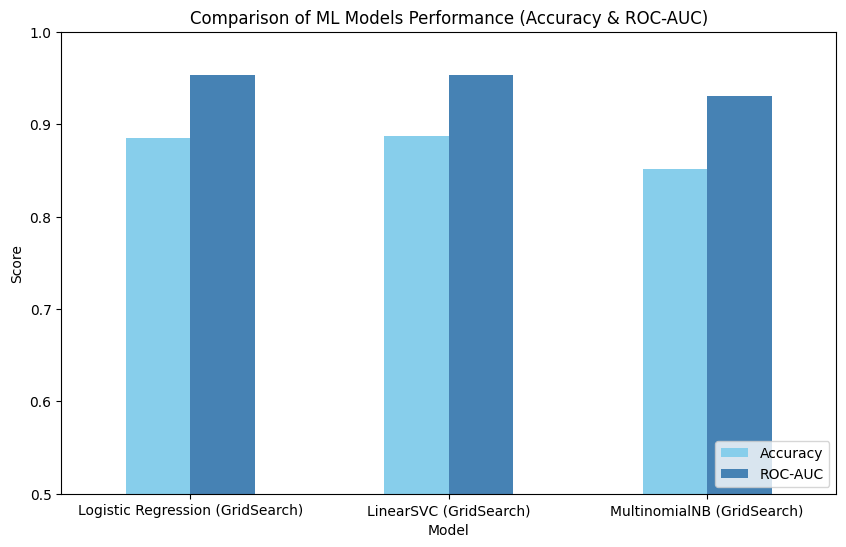

In [35]:
# Plot Bar Chart dengan warna biru awan (sky blue tones)
colors = ['#87CEEB', '#4682B4', '#1E90FF']  # SkyBlue, SteelBlue, DodgerBlue
results_df.set_index('Model')[['Accuracy', 'ROC-AUC']].plot(kind='bar', figsize=(10, 6), color=colors)
plt.title('Comparison of ML Models Performance (Accuracy & ROC-AUC)')
plt.ylabel('Score')
plt.ylim(0.5, 1.0)
plt.xticks(rotation=0)
plt.legend(loc='lower right')
plt.show()

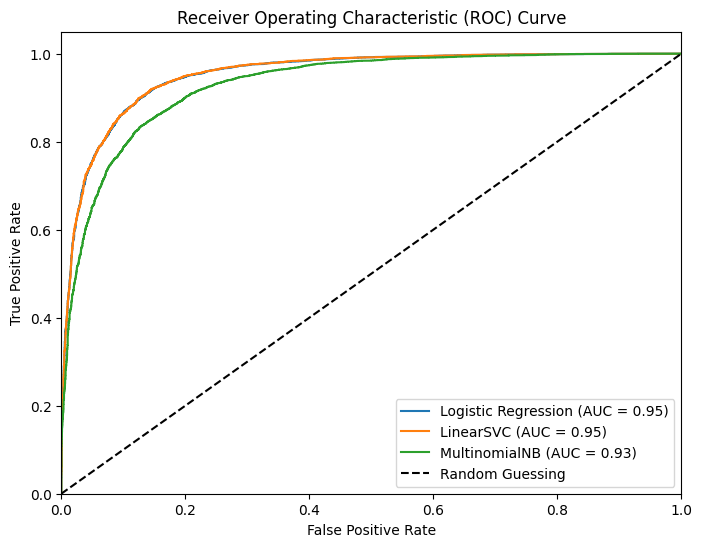

In [36]:
# Plot ROC Curve
plt.figure(figsize=(8, 6))
for model_name, (fpr, tpr, auc_score) in roc_data.items():
    plt.plot(fpr, tpr, label=f'{model_name} (AUC = {auc_score:.2f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random Guessing')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()